       PCA AND CLUSTERING TASK - TITANIC DATASET
                Register No: 24EU02039

1. ORIGINAL DATASET
--------------------------------------------------
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape: (891, 15)

2. PREPROCESSED DATA
-----------

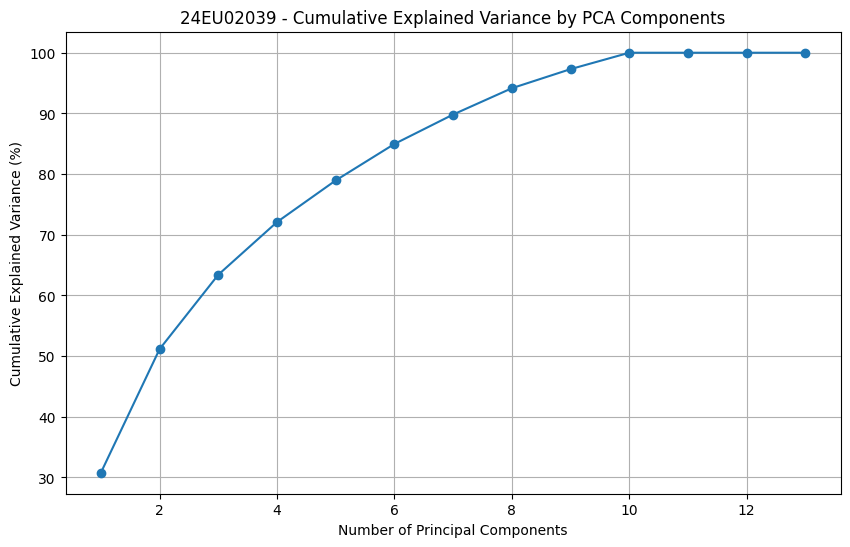


6. PCA WITH 2 COMPONENTS
--------------------------------------------------
PC1 Explained Variance: 30.77%
PC2 Explained Variance: 20.38%
Total Explained Variance: 51.15%


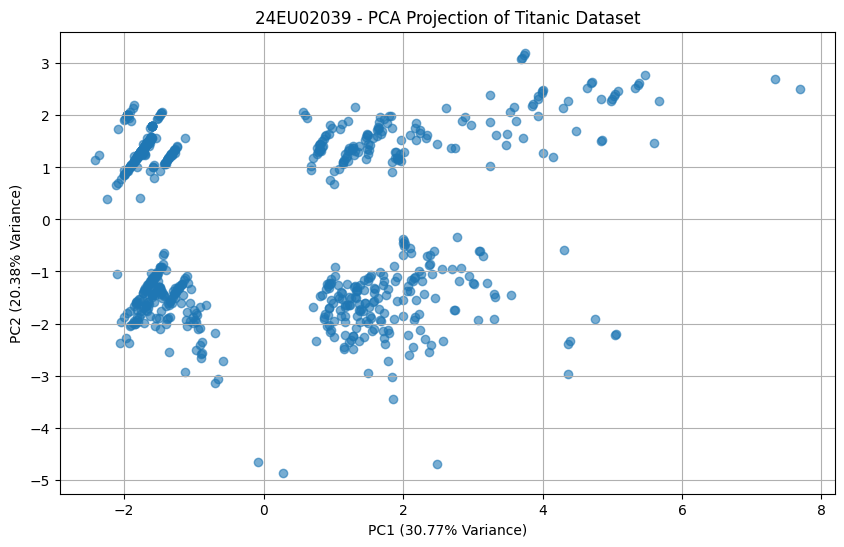

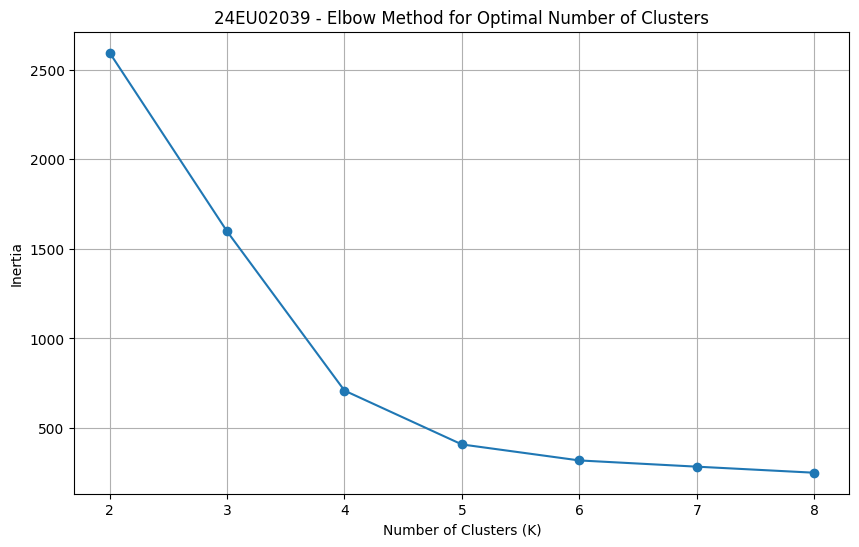


7. SILHOUETTE SCORES
--------------------------------------------------
K = 2 : Silhouette Score = 0.5050
K = 3 : Silhouette Score = 0.5464
K = 4 : Silhouette Score = 0.6981
K = 5 : Silhouette Score = 0.7255
K = 6 : Silhouette Score = 0.6932
K = 7 : Silhouette Score = 0.6814
K = 8 : Silhouette Score = 0.6687


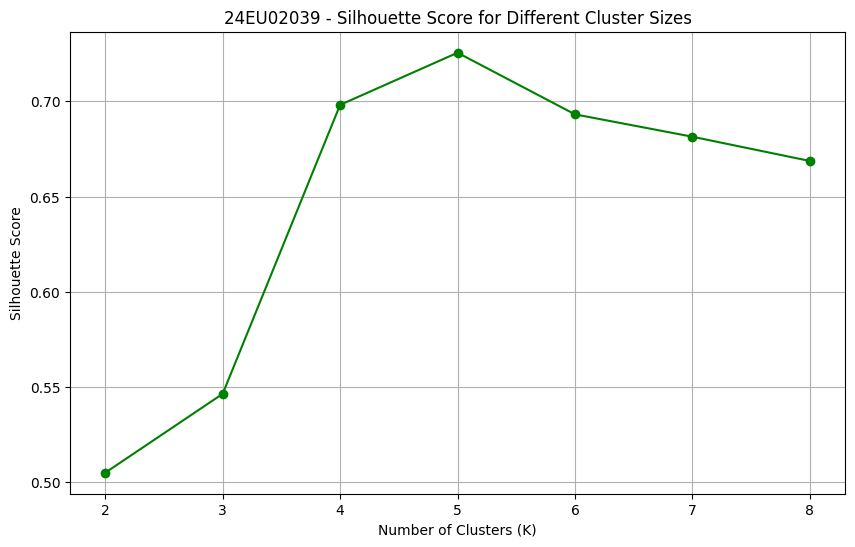


8. OPTIMAL NUMBER OF CLUSTERS
--------------------------------------------------
Best K: 5
Best Silhouette Score: 0.7255

9. K-MEANS CLUSTERING
--------------------------------------------------
K-Means clustering completed successfully.

Number of passengers in each cluster:
Cluster
0    186
1    248
2    105
3    188
4     48
Name: count, dtype: int64


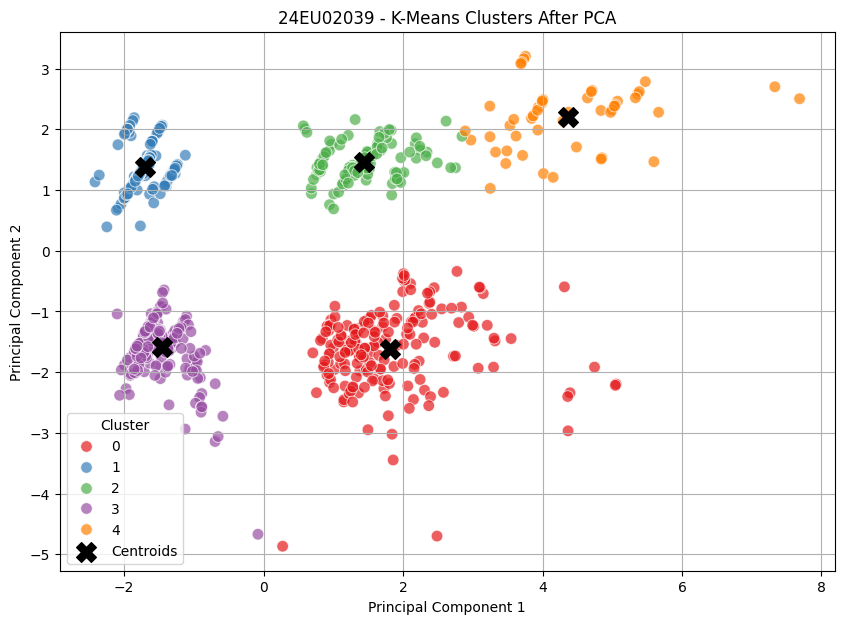

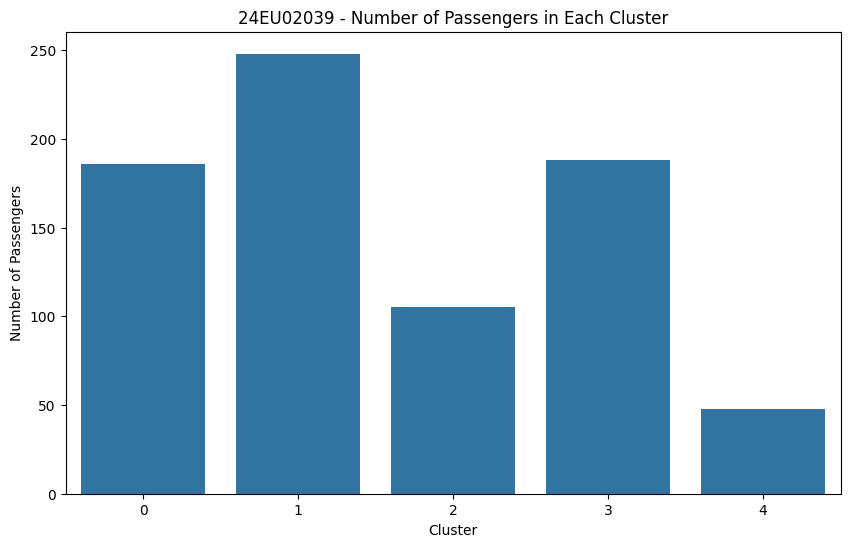


10. CLUSTER PROFILE
--------------------------------------------------
         survived  pclass   sex    age  sibsp  parch   fare  family_size  \
Cluster                                                                    
0            0.69    1.42  0.56  31.10   0.87   0.79  75.49         2.66   
1            0.24    3.00  0.21  28.40   0.00   0.00   9.09         1.00   
2            0.38    3.00  0.50  23.50   0.90   0.68  15.04         2.57   
3            0.46    1.46  0.32  36.46   0.00   0.00  40.11         1.00   
4            0.10    3.00  0.50  16.16   3.21   2.25  33.67         6.46   

         is_alone  class_Second  class_Third  embarked_Q  embarked_S  \
Cluster                                                                
0            0.01          0.42          0.0        0.01        0.69   
1            1.00          0.00          1.0        0.15        0.73   
2            0.00          0.00          1.0        0.10        0.67   
3            1.00          0.46    

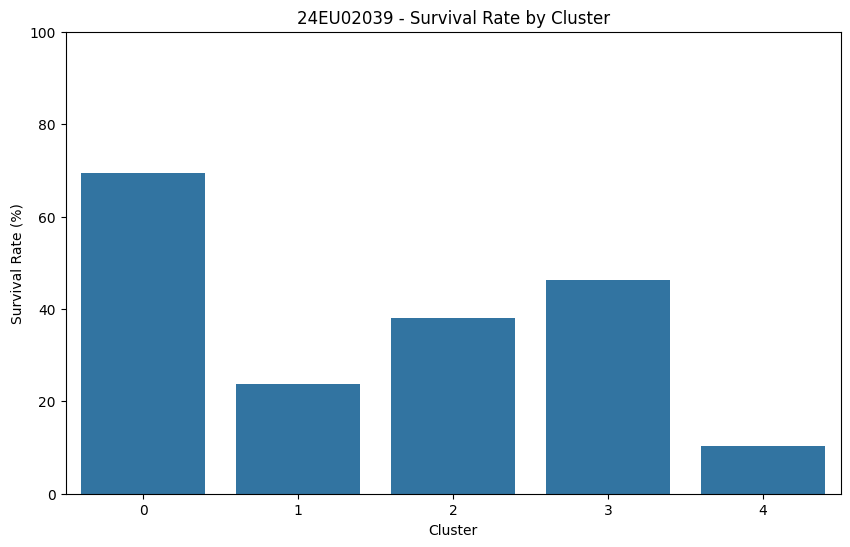


12. PCA COMPONENT LOADINGS
--------------------------------------------------
                PC1    PC2
pclass       -0.042  0.570
sex           0.172 -0.096
age          -0.151 -0.281
sibsp         0.388  0.129
parch         0.377  0.054
fare          0.164 -0.343
family_size   0.460  0.114
is_alone     -0.453  0.037
class_Second  0.011 -0.238
class_Third  -0.040  0.584
embarked_Q   -0.049  0.188
embarked_S    0.009  0.020
alone_True   -0.453  0.037


<Figure size 1200x700 with 0 Axes>

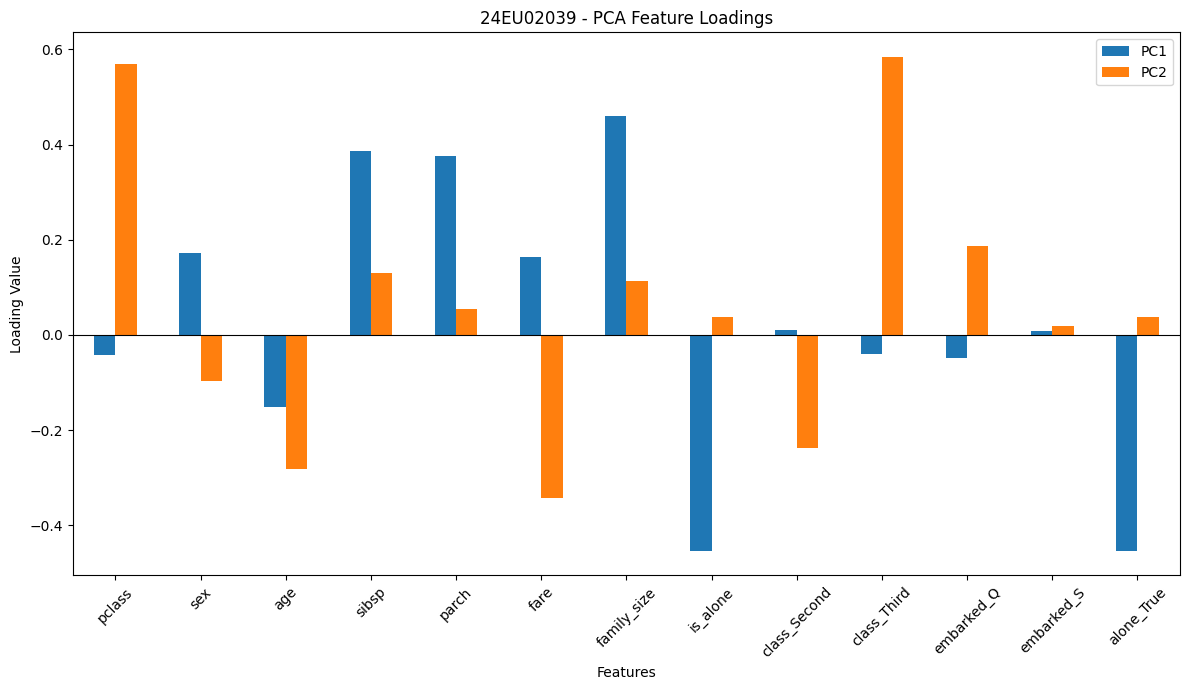



                    FINAL RESULTS

Original Dataset Shape: (891, 15)
Preprocessed Dataset Shape: (775, 15)

Number of PCA Components for Visualization: 2
PC1 Explained Variance: 30.77%
PC2 Explained Variance: 20.38%
Combined Explained Variance: 51.15%

Optimal Number of Clusters: 5
Silhouette Score: 0.7255

Cluster Distribution:
Cluster
0    186
1    248
2    105
3    188
4     48
Name: count, dtype: int64


                       CONCLUSION

The Titanic dataset was used to perform PCA and
K-Means clustering.

Preprocessing steps included:
- Handling missing values
- Encoding categorical variables
- Creating family_size and is_alone features
- Removing unnecessary columns
- Standardizing numerical features

PCA was applied to reduce the dimensionality of the dataset.

The first two principal components were used to visualize
the passenger data in a two-dimensional space.

K-Means clustering was then applied to the PCA-transformed data.

The Elbow Method and Silhouette Score were used

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("=" * 70)
print("       PCA AND CLUSTERING TASK - TITANIC DATASET")
print("                Register No: 24EU02039")
print("=" * 70)


# ============================================================
# 2. LOAD TITANIC DATASET
# ============================================================

df = sns.load_dataset('titanic')

print("\n1. ORIGINAL DATASET")
print("-" * 50)
print(df.head())

print("\nDataset Shape:", df.shape)


# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Remove columns that are not useful for PCA/Clustering
df.drop(
    columns=['deck', 'alive', 'embark_town', 'who', 'adult_male'],
    inplace=True,
    errors='ignore'
)

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Create Family Size
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Create Is Alone
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Encode Sex
df['sex'] = df['sex'].map({
    'male': 0,
    'female': 1
})

# Convert categorical columns to numerical form
df = pd.get_dummies(
    df,
    columns=['class', 'embarked', 'alone'],
    drop_first=True,
    dtype=int
)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\n2. PREPROCESSED DATA")
print("-" * 50)
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. PREPARE DATA FOR PCA
# ============================================================

# Do not use survived as an input feature because clustering
# should discover passenger groups without using the survival label.

if 'survived' in df.columns:
    X = df.drop('survived', axis=1)
else:
    X = df.copy()

print("\n3. FEATURES USED FOR PCA AND CLUSTERING")
print("-" * 50)
print(X.columns.tolist())

print("\nNumber of Features:", X.shape[1])


# ============================================================
# 5. STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\n4. STANDARDIZATION")
print("-" * 50)
print("All features have been standardized using StandardScaler.")


# ============================================================
# 6. APPLY PCA
# ============================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(
    explained_variance
)

print("\n5. PCA EXPLAINED VARIANCE")
print("-" * 50)

for i, variance in enumerate(
    explained_variance,
    start=1
):
    print(
        f"Principal Component {i}: "
        f"{variance * 100:.2f}%"
    )

print(
    "\nTotal Explained Variance:",
    f"{cumulative_variance[-1] * 100:.2f}%"
)


# ============================================================
# 7. EXPLAINED VARIANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    cumulative_variance * 100,
    marker='o'
)

plt.title(
    '24EU02039 - Cumulative Explained Variance by PCA Components'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')

plt.grid(True)

plt.show()


# ============================================================
# 8. SELECT PCA COMPONENTS
# ============================================================

# Select the first two principal components for visualization

pca_2 = PCA(
    n_components=2
)

X_pca_2 = pca_2.fit_transform(
    X_scaled
)

print("\n6. PCA WITH 2 COMPONENTS")
print("-" * 50)

print(
    "PC1 Explained Variance:",
    f"{pca_2.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    "PC2 Explained Variance:",
    f"{pca_2.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    "Total Explained Variance:",
    f"{sum(pca_2.explained_variance_ratio_) * 100:.2f}%"
)


# ============================================================
# 9. PCA SCATTER PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    alpha=0.6
)

plt.title(
    '24EU02039 - PCA Projection of Titanic Dataset'
)

plt.xlabel(
    f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.2f}% Variance)"
)

plt.ylabel(
    f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.2f}% Variance)"
)

plt.grid(True)

plt.show()


# ============================================================
# 10. ELBOW METHOD FOR K-MEANS
# ============================================================

inertia = []

K = range(2, 9)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca_2)

    inertia.append(
        kmeans.inertia_
    )


# ============================================================
# 11. ELBOW GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.title(
    '24EU02039 - Elbow Method for Optimal Number of Clusters'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.grid(True)

plt.show()


# ============================================================
# 12. SILHOUETTE SCORE FOR DIFFERENT K VALUES
# ============================================================

silhouette_scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_pca_2
    )

    score = silhouette_score(
        X_pca_2,
        labels
    )

    silhouette_scores.append(score)

print("\n7. SILHOUETTE SCORES")
print("-" * 50)

for k, score in zip(
    K,
    silhouette_scores
):
    print(
        f"K = {k} : "
        f"Silhouette Score = {score:.4f}"
    )


# ============================================================
# 13. SILHOUETTE SCORE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    K,
    silhouette_scores,
    marker='o',
    color='green'
)

plt.title(
    '24EU02039 - Silhouette Score for Different Cluster Sizes'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.grid(True)

plt.show()


# ============================================================
# 14. SELECT BEST K
# ============================================================

best_k = K[
    np.argmax(silhouette_scores)
]

best_silhouette = max(
    silhouette_scores
)

print("\n8. OPTIMAL NUMBER OF CLUSTERS")
print("-" * 50)

print("Best K:", best_k)
print(
    "Best Silhouette Score:",
    round(best_silhouette, 4)
)


# ============================================================
# 15. APPLY K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_pca_2
)

# Add cluster labels to dataframe
df['Cluster'] = clusters

print("\n9. K-MEANS CLUSTERING")
print("-" * 50)

print(
    "K-Means clustering completed successfully."
)

print(
    "\nNumber of passengers in each cluster:"
)

print(
    df['Cluster'].value_counts().sort_index()
)


# ============================================================
# 16. PCA + K-MEANS CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca_2[:, 0],
    y=X_pca_2[:, 1],
    hue=clusters,
    palette='Set1',
    s=70,
    alpha=0.7
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title(
    '24EU02039 - K-Means Clusters After PCA'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
    title='Cluster'
)

plt.grid(True)

plt.show()


# ============================================================
# 17. CLUSTER DISTRIBUTION
# ============================================================

cluster_counts = (
    df['Cluster']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title(
    '24EU02039 - Number of Passengers in Each Cluster'
)

plt.xlabel('Cluster')
plt.ylabel('Number of Passengers')

plt.show()


# ============================================================
# 18. CLUSTER PROFILE
# ============================================================

print("\n10. CLUSTER PROFILE")
print("-" * 50)

# Display numerical cluster means
cluster_profile = (
    df.groupby('Cluster')
    .mean(numeric_only=True)
)

print(
    cluster_profile.round(2)
)


# ============================================================
# 19. CLUSTER VS SURVIVAL
# ============================================================

# Survival was NOT used for clustering.
# It is only used here to interpret the resulting clusters.

if 'survived' in df.columns:

    survival_by_cluster = (
        df.groupby('Cluster')['survived']
        .mean()
        .mul(100)
        .round(2)
    )

    print("\n11. SURVIVAL RATE BY CLUSTER")
    print("-" * 50)

    print(
        survival_by_cluster
    )


    # Graph - Cluster vs Survival
    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=survival_by_cluster.index,
        y=survival_by_cluster.values
    )

    plt.title(
        '24EU02039 - Survival Rate by Cluster'
    )

    plt.xlabel('Cluster')
    plt.ylabel('Survival Rate (%)')

    plt.ylim(0, 100)

    plt.show()


# ============================================================
# 20. PCA COMPONENT LOADINGS
# ============================================================

loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\n12. PCA COMPONENT LOADINGS")
print("-" * 50)

print(
    loadings.round(3)
)


# ============================================================
# 21. PCA LOADING GRAPH
# ============================================================

plt.figure(figsize=(12, 7))

loading_plot = loadings.copy()

loading_plot.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title(
    '24EU02039 - PCA Feature Loadings'
)

plt.xlabel('Features')
plt.ylabel('Loading Value')

plt.xticks(rotation=45)

plt.axhline(
    0,
    color='black',
    linewidth=0.8
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("                    FINAL RESULTS")
print("=" * 70)

print("\nOriginal Dataset Shape:", (891, 15))

print(
    "Preprocessed Dataset Shape:",
    df.shape
)

print(
    "\nNumber of PCA Components for Visualization: 2"
)

print(
    "PC1 Explained Variance:",
    f"{pca_2.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    "PC2 Explained Variance:",
    f"{pca_2.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    "Combined Explained Variance:",
    f"{sum(pca_2.explained_variance_ratio_) * 100:.2f}%"
)

print(
    "\nOptimal Number of Clusters:",
    best_k
)

print(
    "Silhouette Score:",
    round(best_silhouette, 4)
)

print(
    "\nCluster Distribution:"
)

print(
    cluster_counts
)


# ============================================================
# 23. CONCLUSION
# ============================================================

print("\n")
print("=" * 70)
print("                       CONCLUSION")
print("=" * 70)

print(f"""
The Titanic dataset was used to perform PCA and
K-Means clustering.

Preprocessing steps included:
- Handling missing values
- Encoding categorical variables
- Creating family_size and is_alone features
- Removing unnecessary columns
- Standardizing numerical features

PCA was applied to reduce the dimensionality of the dataset.

The first two principal components were used to visualize
the passenger data in a two-dimensional space.

K-Means clustering was then applied to the PCA-transformed data.

The Elbow Method and Silhouette Score were used to determine
an appropriate number of clusters.

Optimal number of clusters:
{best_k}

Silhouette Score:
{best_silhouette:.4f}

The clusters represent groups of Titanic passengers with
similar characteristics based on the features used for
clustering.

Survival was not used to create the clusters. It was only
used afterward to understand the survival characteristics
of the discovered passenger groups.
""")

print("=" * 70)
print("       PCA AND CLUSTERING COMPLETED SUCCESSFULLY")
print("                 24EU02039")
print("=" * 70)
